In [1]:
from numpy import matrix, eye, zeros, concatenate, array, trace as tr, matmul
from cvxpy import Variable, Problem, Maximize, trace, real, partial_trace
from matplotlib.pyplot import rcParams, subplots, legend, savefig, show
from qiskit.quantum_info import random_statevector, DensityMatrix
from math import sqrt

In [2]:
size = 20
params = {
          'figure.figsize': (10, 7),
          'legend.fontsize': size,
          'axes.labelsize': size,
          'xtick.labelsize': size,
          'ytick.labelsize': size,
         }
rcParams.update(params)

In [3]:
def vec(A):
    return matrix(concatenate(array(A), axis = None)).conjugate()

In [4]:
n = 1
NUM = 10000

X = Variable((2**(2*n), 2**(2*n)), hermitian=True)

constraints = [X >> 0]
constraints += [partial_trace(X, (2, 2), 1) == eye(2**n)]

In [5]:
fid = [0 for _ in range(6)]
fidnc = [0 for _ in range(6)]
states = [DensityMatrix(random_statevector(2)).data for _ in range(NUM)]
for rho in states:
    for gamma in range(6):
        E = [eye(2**n), zeros((2**n, 2**n))]
        E[0][1][1] = sqrt(1-gamma/10)
        E[1][0][1] = sqrt(gamma/10)

        C_ = [vec(rho@E[0]), vec(rho@E[1])]

        C = C_[0].getH().dot(C_[0]) + C_[1].getH().dot(C_[1])

        prob = Problem(Maximize(real(trace(X@C))), constraints)
        fid[gamma] += prob.solve()/NUM
        
        fidnc[gamma] += abs(tr(matmul(rho, E[0]) + matmul(rho, E[1])))**2/NUM

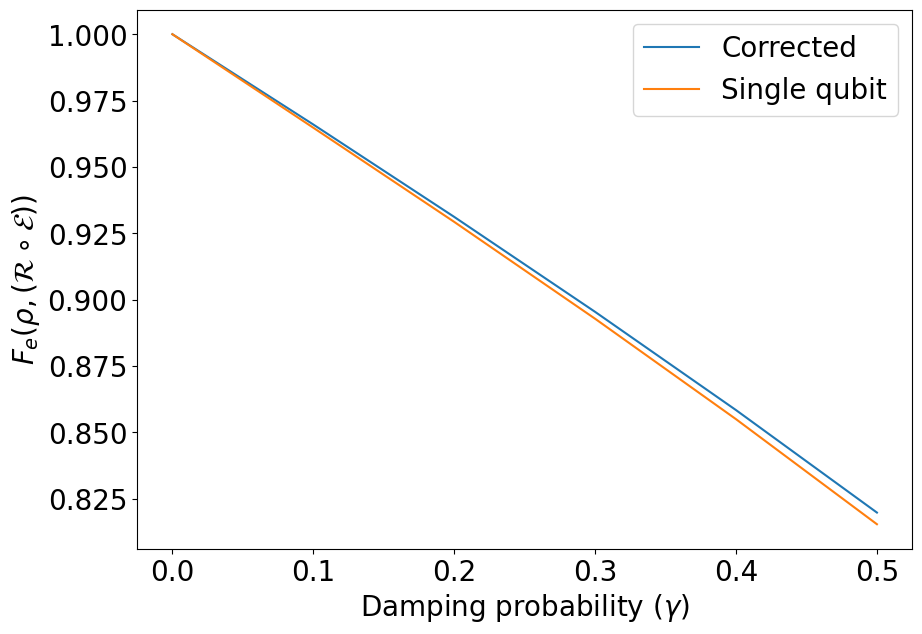

In [6]:
_, ax = subplots(1, 1)
ax.plot([gamma/10 for gamma in range(6)], fid, label = "Corrected")
ax.plot([gamma/10 for gamma in range(6)], fidnc, label = "Single qubit")
# ax.plot([gamma/10 for gamma in range(6)], fid1, label = "Excited state")
ax.set_xlabel(r'Damping probability $(\gamma)$')
ax.set_ylabel(r'$F_e(\rho,(\mathcal{R}\circ\mathcal{E}))$')
legend()
show()